# 🎙️ Speech Emotion Recognition

## Task 2 — Feature Extraction

In this notebook, we extract **MFCC (Mel-Frequency Cepstral Coefficients)**
features from the RAVDESS speech emotion dataset.

### Objectives

- Load audio dataset
- Extract MFCC features
- Verify feature dimensions
- Visualize sample MFCC
- Analyze extracted features
- Save feature dataset for model training

### Feature Configuration

- Sample Rate: 22050 Hz
- MFCC Coefficients: 40
- Time Steps: 94
- Expected Samples: 1440

## 1. Import Libraries

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from IPython.display import Audio, display

warnings.filterwarnings("ignore")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Dataset Configuration

The RAVDESS dataset is located inside:

`dataset/RAVDESS/`

All `.wav` files are searched recursively.

In [2]:
DATASET_PATH = "../dataset/RAVDESS"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {os.path.abspath(DATASET_PATH)}"
    )

audio_files = sorted(
    glob.glob(
        os.path.join(DATASET_PATH, "**", "*.wav"),
        recursive=True
    )
)

print("Dataset Path:")
print(os.path.abspath(DATASET_PATH))

print(f"\nTotal audio files: {len(audio_files)}")

Dataset Path:
c:\Users\harsh\OneDrive\Desktop\CodeAlpha_EmotionRecognition\dataset\RAVDESS

Total audio files: 1440


## 3. Emotion Label Mapping

RAVDESS filenames contain numerical emotion codes.

| Code | Emotion |
|------|---------|
| 01 | Neutral |
| 02 | Calm |
| 03 | Happy |
| 04 | Sad |
| 05 | Angry |
| 06 | Fearful |
| 07 | Disgust |
| 08 | Surprised |

In [3]:
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


def get_emotion(file_path):
    filename = os.path.basename(file_path)

    parts = filename.replace(".wav", "").split("-")

    if len(parts) >= 3:
        emotion_code = parts[2]
        return EMOTION_MAP.get(emotion_code, "unknown")

    return "unknown"


print("Emotion labels:")

for code, emotion in EMOTION_MAP.items():
    print(f"{code} → {emotion}")

Emotion labels:
01 → neutral
02 → calm
03 → happy
04 → sad
05 → angry
06 → fearful
07 → disgust
08 → surprised


## 4. MFCC Configuration

MFCC is used to represent important spectral characteristics
of human speech.

For this project:

- Sample Rate = 22050 Hz
- MFCC = 40
- Time Steps = 94

Therefore, every audio file will produce:

`40 × 94`

MFCC features.

In [4]:
SAMPLE_RATE = 22050
N_MFCC = 40
TARGET_TIME_STEPS = 94

print("MFCC Configuration")
print("-------------------")
print(f"Sample Rate       : {SAMPLE_RATE} Hz")
print(f"MFCC Coefficients : {N_MFCC}")
print(f"Time Steps        : {TARGET_TIME_STEPS}")

MFCC Configuration
-------------------
Sample Rate       : 22050 Hz
MFCC Coefficients : 40
Time Steps        : 94


## 5. MFCC Extraction Function

The function below:

1. Loads the audio
2. Converts it to the required sample rate
3. Extracts 40 MFCC coefficients
4. Pads or trims the temporal dimension
5. Returns a fixed `(40, 94)` feature matrix

In [5]:
def extract_mfcc(
    file_path,
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    target_time_steps=TARGET_TIME_STEPS
):
    try:
        audio, sr = librosa.load(
            file_path,
            sr=sample_rate
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=n_mfcc
        )

        # Pad if shorter
        if mfcc.shape[1] < target_time_steps:

            mfcc = np.pad(
                mfcc,
                (
                    (0, 0),
                    (0, target_time_steps - mfcc.shape[1])
                ),
                mode="constant"
            )

        # Trim if longer
        else:

            mfcc = mfcc[:, :target_time_steps]

        return mfcc.astype(np.float32)

    except Exception as error:

        print(f"Error: {file_path}")
        print(error)

        return None

## 6. Test MFCC Extraction on One Audio File

In [6]:
sample_file = audio_files[0]

sample_mfcc = extract_mfcc(sample_file)

print("Sample Audio:")
print(sample_file)

print("\nEmotion:")
print(get_emotion(sample_file))

print("\nMFCC Shape:")
print(sample_mfcc.shape)

Sample Audio:
../dataset/RAVDESS\Actor_01\03-01-01-01-01-01-01.wav

Emotion:
neutral

MFCC Shape:
(40, 94)


In [7]:
print("Playing sample audio:")

display(
    Audio(sample_file)
)

Playing sample audio:


## 7. Sample MFCC Visualization

The following graph shows the MFCC representation of
one speech sample.

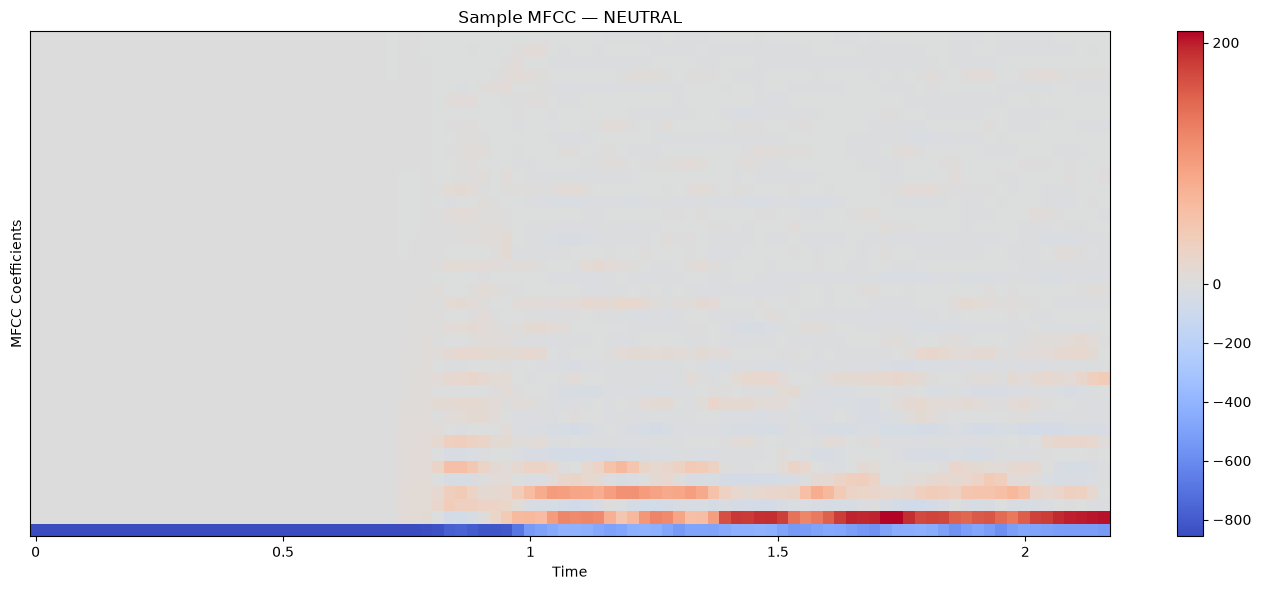

In [8]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    sample_mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title(
    f"Sample MFCC — {get_emotion(sample_file).upper()}"
)

plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")

plt.tight_layout()

plt.show()

## 8. MFCC Statistics

In [9]:
print("MFCC Statistics")
print("================")

print(f"Minimum : {sample_mfcc.min():.4f}")
print(f"Maximum : {sample_mfcc.max():.4f}")
print(f"Mean    : {sample_mfcc.mean():.4f}")
print(f"Std     : {sample_mfcc.std():.4f}")

MFCC Statistics
Minimum : -857.3381
Maximum : 209.3295
Mean    : -16.8662
Std     : 107.7152


## 9. Extract MFCC Features from Complete Dataset

Now we extract MFCC features from all RAVDESS audio files.

Expected result:

`(1440, 40, 94)`

In [10]:
features = []
labels = []
valid_files = []

total_files = len(audio_files)

print("Starting MFCC extraction...")
print()

for index, file_path in enumerate(audio_files, start=1):

    mfcc = extract_mfcc(file_path)

    if mfcc is not None:

        features.append(mfcc)
        labels.append(get_emotion(file_path))
        valid_files.append(file_path)

    if index % 100 == 0 or index == total_files:

        print(
            f"Processed: {index}/{total_files}"
        )


X = np.array(
    features,
    dtype=np.float32
)

y = np.array(labels)

print("\n✓ Feature extraction completed!")

Starting MFCC extraction...

Processed: 100/1440
Processed: 200/1440
Processed: 300/1440
Processed: 400/1440
Processed: 500/1440
Processed: 600/1440
Processed: 700/1440
Processed: 800/1440
Processed: 900/1440
Processed: 1000/1440
Processed: 1100/1440
Processed: 1200/1440
Processed: 1300/1440
Processed: 1400/1440
Processed: 1440/1440

✓ Feature extraction completed!


## 10. Feature Dataset Shape

In [11]:
print("Feature Dataset Information")
print("===========================")

print(f"Feature Shape : {X.shape}")
print(f"Label Shape   : {y.shape}")

print(f"\nSamples       : {X.shape[0]}")
print(f"MFCC Features : {X.shape[1]}")
print(f"Time Steps    : {X.shape[2]}")

Feature Dataset Information
Feature Shape : (1440, 40, 94)
Label Shape   : (1440,)

Samples       : 1440
MFCC Features : 40
Time Steps    : 94


## 11. Emotion Distribution

In [12]:
emotion_counts = (
    pd.Series(y)
    .value_counts()
    .sort_index()
)

print(emotion_counts)

angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


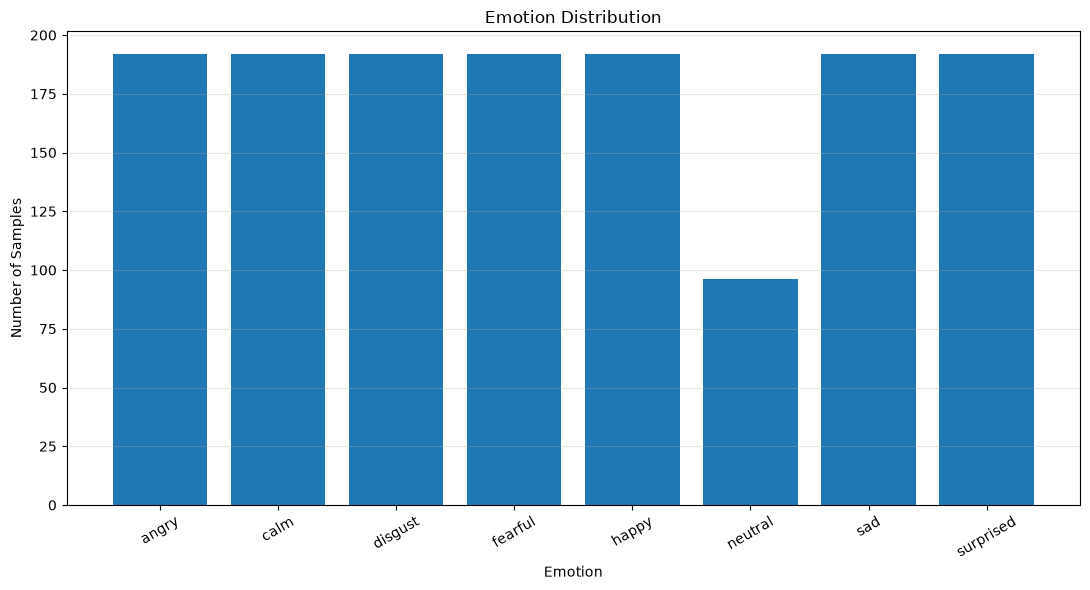

In [13]:
plt.figure(figsize=(11, 6))

plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title("Emotion Distribution")

plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 12. MFCC Visualization for All Emotions

One sample from each emotion category is visualized
to compare their MFCC patterns.

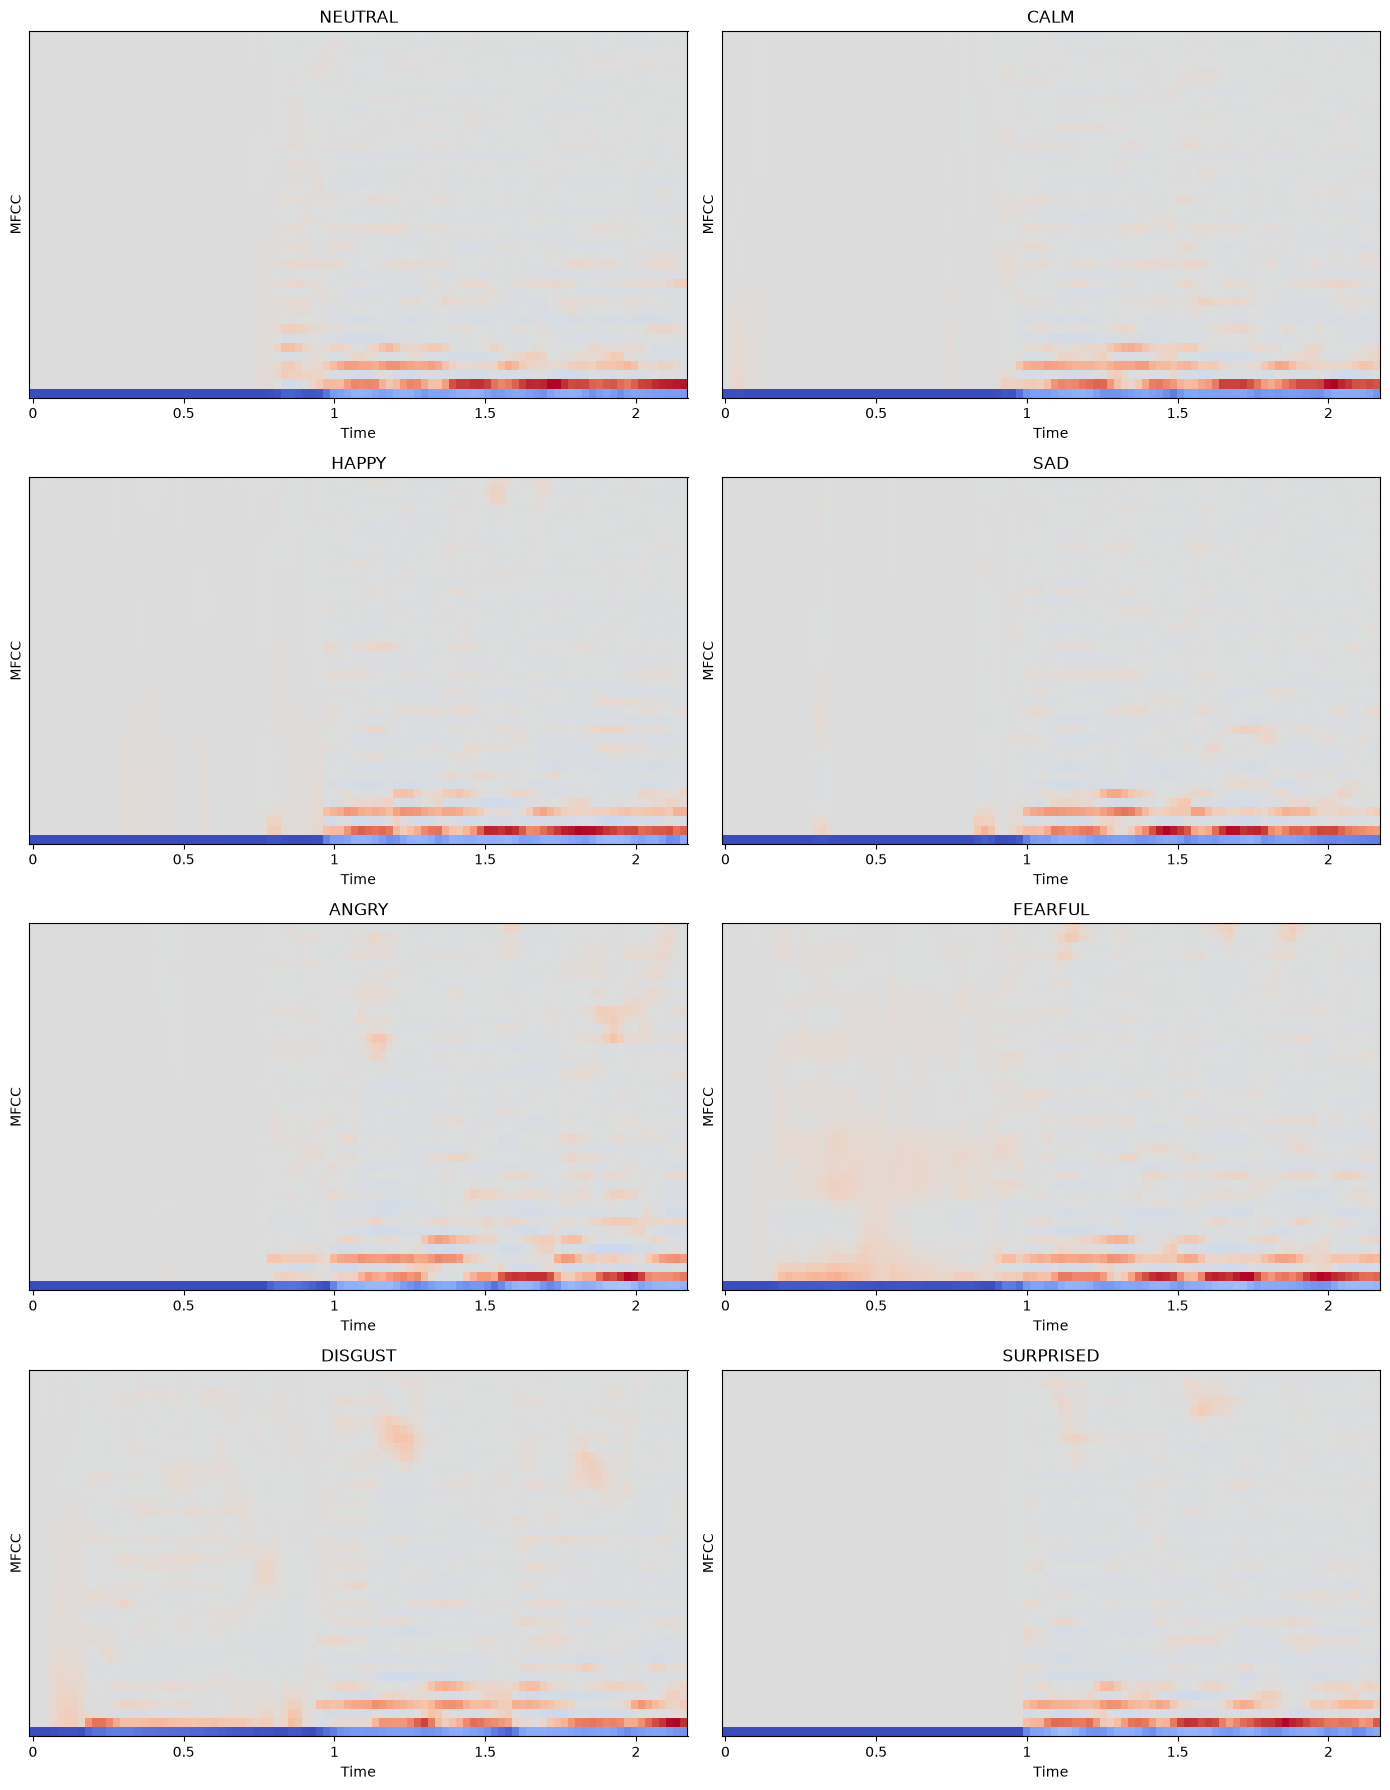

In [14]:
emotion_indices = {}

for emotion in EMOTION_MAP.values():

    indices = np.where(y == emotion)[0]

    if len(indices) > 0:
        emotion_indices[emotion] = indices[0]


plt.figure(figsize=(14, 18))

for position, (emotion, index) in enumerate(
    emotion_indices.items(),
    start=1
):

    ax = plt.subplot(4, 2, position)

    librosa.display.specshow(
        X[index],
        x_axis="time",
        ax=ax
    )

    ax.set_title(
        emotion.upper()
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("MFCC")

plt.tight_layout()

plt.show()

## 13.Mean MFCC Profile

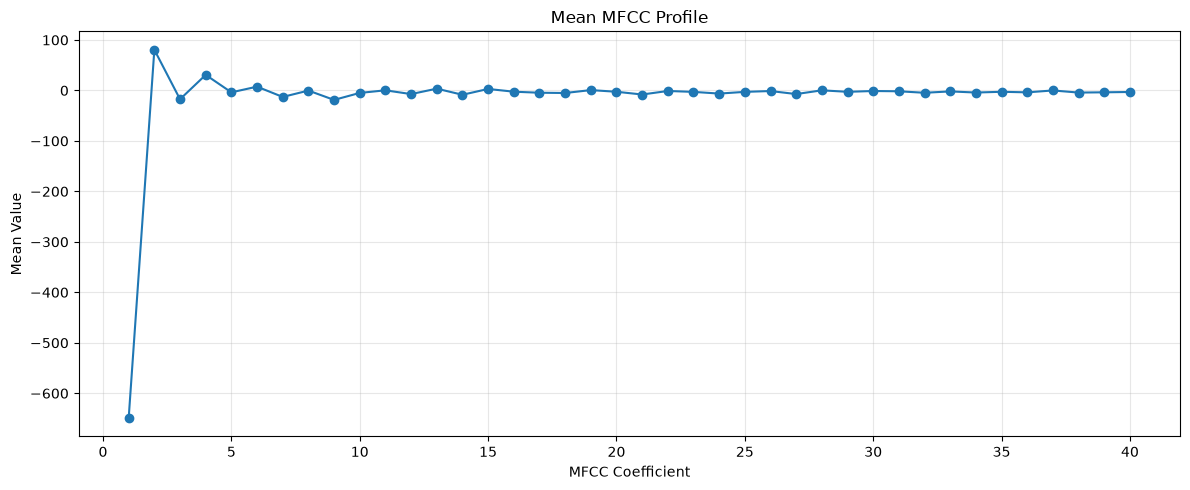

In [15]:
mean_mfcc = sample_mfcc.mean(axis=1)

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, N_MFCC + 1),
    mean_mfcc,
    marker="o"
)

plt.title("Mean MFCC Profile")

plt.xlabel("MFCC Coefficient")
plt.ylabel("Mean Value")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 14. Save Extracted Feature Dataset

The extracted MFCC features and labels will be stored
inside the `outputs` folder.

These files will later be used by the model training pipeline.

In [16]:
OUTPUT_DIR = "../outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

FEATURE_FILE = os.path.join(
    OUTPUT_DIR,
    "mfcc_features.npy"
)

LABEL_FILE = os.path.join(
    OUTPUT_DIR,
    "mfcc_labels.npy"
)

FILE_LIST = os.path.join(
    OUTPUT_DIR,
    "mfcc_files.txt"
)


np.save(
    FEATURE_FILE,
    X
)

np.save(
    LABEL_FILE,
    y
)

with open(
    FILE_LIST,
    "w",
    encoding="utf-8"
) as file:

    for path in valid_files:
        file.write(path + "\n")


print("✓ Feature dataset saved successfully!")

print("\nFiles:")
print(FEATURE_FILE)
print(LABEL_FILE)
print(FILE_LIST)

✓ Feature dataset saved successfully!

Files:
../outputs\mfcc_features.npy
../outputs\mfcc_labels.npy
../outputs\mfcc_files.txt


## 15. Verify Saved Feature Dataset

In [17]:
X_check = np.load(
    FEATURE_FILE
)

y_check = np.load(
    LABEL_FILE,
    allow_pickle=True
)

print("Saved Dataset Verification")
print("===========================")

print(
    "Features:",
    X_check.shape
)

print(
    "Labels:",
    y_check.shape
)

if X_check.shape == X.shape and len(y_check) == len(y):

    print(
        "\n✓ Saved dataset verified successfully!"
    )

else:

    print(
        "\n⚠ Verification failed!"
    )

Saved Dataset Verification
Features: (1440, 40, 94)
Labels: (1440,)

✓ Saved dataset verified successfully!


# Conclusion

The feature extraction stage was successfully completed using
MFCC (Mel-Frequency Cepstral Coefficients) from the RAVDESS
speech emotion dataset.

The audio files were processed and converted into fixed-size
MFCC feature matrices of 40 coefficients and 94 time steps.
Sample MFCC visualizations and emotion distribution graphs were
also generated to understand the extracted features.

The extracted features and corresponding emotion labels were
successfully saved for use in the model training stage.

